# Physics-informed lattice-site ptychography at glancing incidence

The direct inverse problem assigns one parameter to every selected potential pixel. Here, the known silicon lattice and Lobato atomic potential instead define

$$
V(s,u)=V_{\mathrm{ref}}(s,u)+\sum_i\left[(1-d_i)K_i(s-\Delta s_i,u-\Delta u_i)-K_i(s,u)\right].
$$

Each $d_i$ is a vacancy fraction, while a coarse displacement grid generates the site shifts $(\Delta s_i,\Delta u_i)$. The angular-spectrum forward model and diffraction loss are unchanged. The notebook first constructs and explores the synthetic experiment, then runs the inverse problem through the same compact API.


In [1]:
%matplotlib widget

import jax

from wide_angle_propagation.notebook_utils import resolve_repo_root
from wide_angle_propagation.ptychography_workflow_1d import (
    ReconstructionOptions1D,
    SiliconGlancingConfig1D,
    build_silicon_glancing_experiment_1d,
    make_glancing_scan_viewer_1d,
    plot_experiment_overview_1d,
    plot_lattice_reconstruction_1d,
    plot_reconstruction_comparison_1d,
    reconstruct_experiment_1d,
    reconstruction_metrics_1d,
    save_experiment_results_1d,
    simulate_experiment_1d,
)

jax.config.update("jax_enable_x64", True)


## 1. Construct the matched experiment

`SiliconGlancingConfig1D` keeps the physical and numerical defaults in one place. The default `update_region="landing"` is deliberately conservative: only Si sites in a shallow strip around the scanned surface landings can change. The rest of the 50 Å slab remains in the known pristine reference potential, so the inverse model does not assign unsupported deep structure.


In [2]:
config = SiliconGlancingConfig1D(
    update_region="landing",
    landing_radius_waists=3.0,
)
experiment = build_silicon_glancing_experiment_1d(config)
experiment.summary


{'potential shape': (2946, 2318),
 'sampling (ds, du) A': (0.3394375, 0.1467837837837838),
 'scan count': 300,
 'pixel unknowns': 39866,
 'update region': 'landing',
 'landing radius (A)': 9.0,
 'landing depth (A)': 9.0,
 'variable Si sites': 563,
 'displacement controls': 44,
 'lattice parameters': 607,
 'pixel / lattice reduction': 65.67710049423394,
 'explicit vacancy sites': 10}

The landing support extends three probe waists laterally beyond the scan range and three waists below the surface by default. Use `update_region="beam_path"` only when the scientific question requires the earlier, less conservative ray-tube support.


## 2. Simulate one truth case

Choose either `"vacancy"` or `"vacancy_plus_strain"`. The returned dataset contains the measured diffraction stack and two diagnostics: the error caused by deleting the known exterior potential, and the error caused by truncating the atomic template at 8 Å.


In [3]:
DATASET_CASE = "vacancy"  # or "vacancy_plus_strain"
dataset = simulate_experiment_1d(experiment, DATASET_CASE, batch_size=10)

{
    **experiment.summary,
    "zero-exterior amplitude NRMSE": dataset.zero_exterior_amplitude_nrmse,
    "template-cutoff amplitude NRMSE": dataset.template_cutoff_amplitude_nrmse,
}


{'potential shape': (2946, 2318),
 'sampling (ds, du) A': (0.3394375, 0.1467837837837838),
 'scan count': 300,
 'pixel unknowns': 39866,
 'update region': 'landing',
 'landing radius (A)': 9.0,
 'landing depth (A)': 9.0,
 'variable Si sites': 563,
 'displacement controls': 44,
 'lattice parameters': 607,
 'pixel / lattice reduction': 65.67710049423394,
 'explicit vacancy sites': 10,
 'zero-exterior amplitude NRMSE': 0.43035291607806625,
 'template-cutoff amplitude NRMSE': 1.452754978604687e-14}

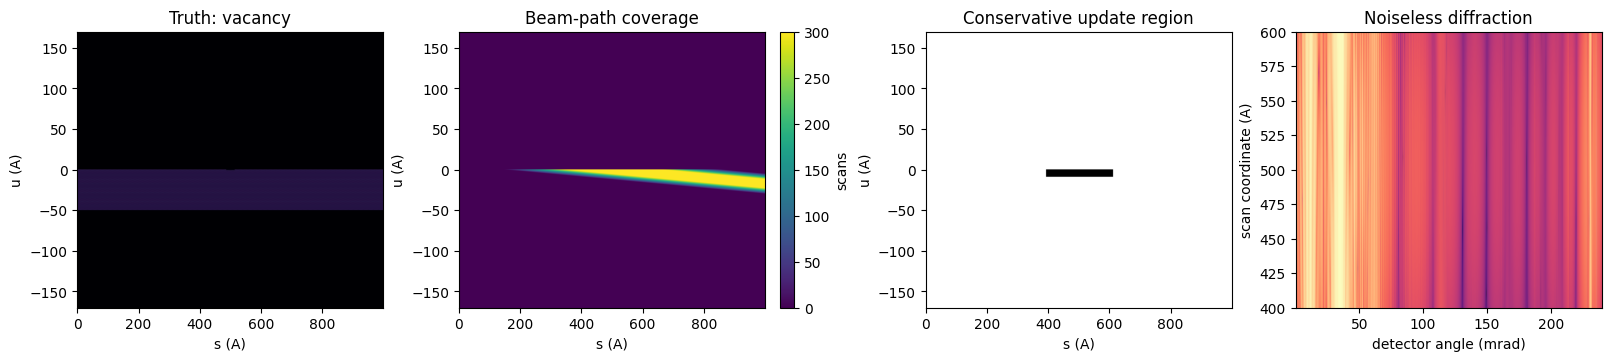

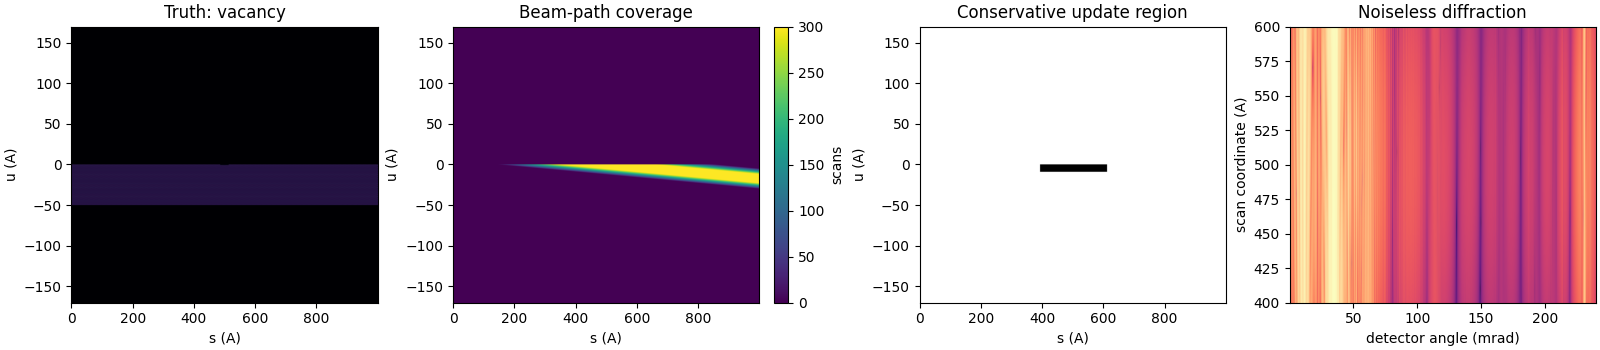

In [4]:
plot_experiment_overview_1d(experiment, dataset)


## 3. Explore the scan before inversion

The linked viewer is deliberately placed before the reconstruction. The slider changes the beam landing position, while the three panels retain the original global side view, exit-wave intensity, and positive-angle diffraction signal. Setting `scan_stride` above one stores fewer side views and enables the checkbox for on-demand positions.


In [5]:
scan_viewer = make_glancing_scan_viewer_1d(
    experiment,
    dataset,
    scan_stride=20,
)
scan_viewer


## 4. Reconstruct the specimen

The lattice-site model is the default scientific reconstruction. TQDM reports every optimizer update in the notebook. Add `"warm_pixels"` to separate the benefit of the pristine initialization from parameter reduction, or add `"blind_pixels"` to reproduce the weak, zero-exterior baseline. In every case, only the conservative landing support is updated; material outside it stays fixed to the pristine reference.


In [7]:
METHODS = ("lattice_sites",)
options = ReconstructionOptions1D(
    lattice_updates=500,
    pixel_updates=4000,
    progress=True,
)

results = reconstruct_experiment_1d(
    experiment,
    dataset,
    methods=METHODS,
    options=options,
)


lattice-site reconstruction:   0%|          | 0/500 [00:00<?, ?update/s]

In [8]:
metrics = reconstruction_metrics_1d(experiment, dataset, results)
metrics


{'lattice sites': {'best update': 500,
  'best validation loss': 1.5301898505996398e-06,
  'potential NRMSE': 0.0823100331302488,
  'time to best (s)': 250.15517438203096,
  'vacancy F1': 1.0,
  'displacement RMSE (A)': 0.025727136375133988,
  'specimen parameters': 607}}

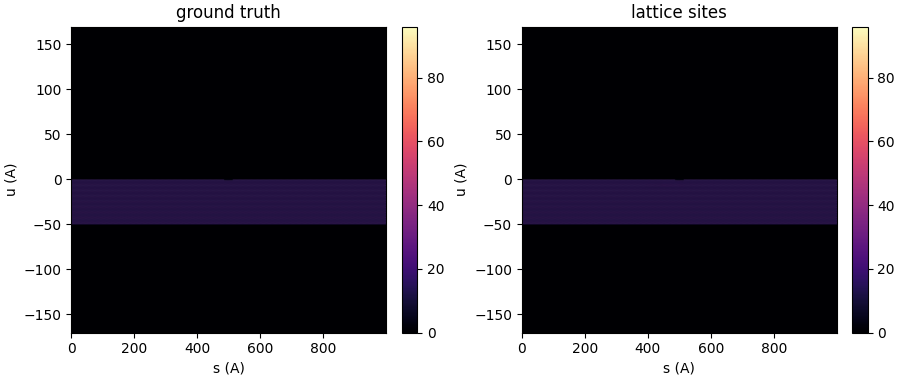

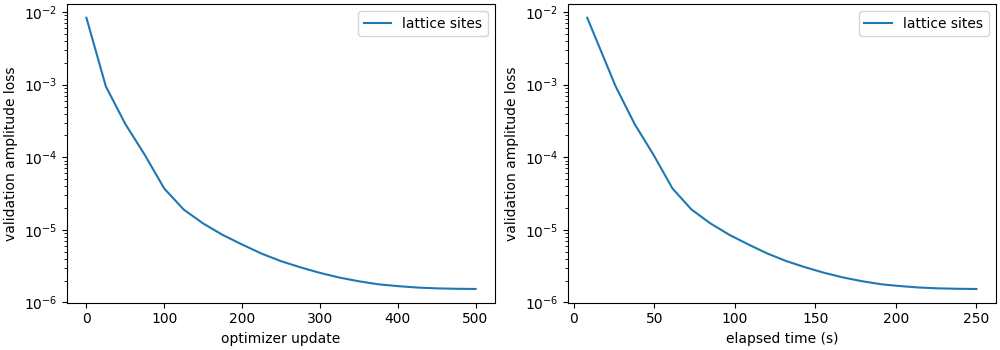

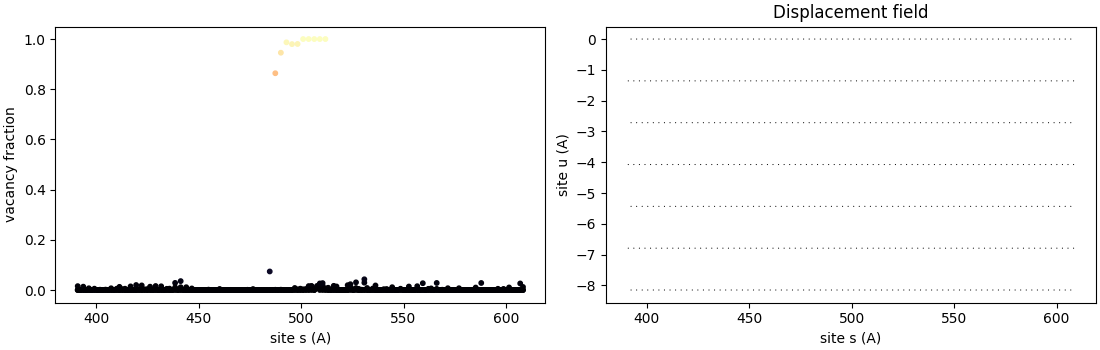

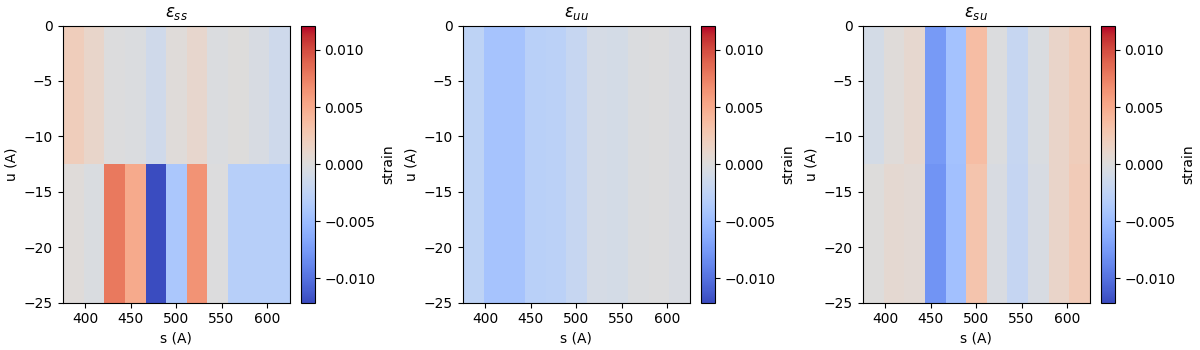

In [9]:
plot_reconstruction_comparison_1d(experiment, dataset, results)

if "lattice sites" in results:
    plot_lattice_reconstruction_1d(experiment, results["lattice sites"])


## 5. Save compact results

The saved arrays contain the data and reconstruction parameters, but not the large temporary side-view cache. This cell is optional and does not change the in-memory workflow.


In [ ]:
result_dir = resolve_repo_root() / "notebook_results" / "sideview_glancing_ptychography_1d"
result_paths = save_experiment_results_1d(result_dir, dataset, results)
result_paths


## Interpretation

The conservative landing support prevents the optimizer from assigning an unconstrained potential throughout the beam-path tube. The known exterior still scatters in every forward model, but it is not treated as reconstructed data. Therefore, a low residual only supports vacancy and strain estimates within the displayed landing region; it does not imply that deeper material has been recovered.

The warm-pixel and lattice-site results answer different questions. Keeping the pristine exterior removes support mismatch, whereas the lattice parameterization additionally restricts the unknown interior to physical occupancies and smooth atomic displacements. Validation loss versus both update count and elapsed time determines whether that restriction improves convergence under the conditions considered here.

The model remains conditional on known Si chemistry, lattice orientation, and candidate sites. It can represent vacancies and smooth strain, but it does not yet include interstitials, substitutions, changes in lattice topology, probe errors, or partial coherence. No interatomic-energy penalty is used, because such a term would add another material model and could bias the reconstruction toward a defect-free equilibrium.
